# Práctica Desempeño: Implementación del algoritmo Naive Bayes (Gaussian Naive Bayes)
## Dataset: Breast Cancer Wisconsin (incluido en scikit-learn)

Contexto del Problema
El dataset contiene características calculadas a partir de imágenes digitalizadas de aspiraciones con aguja fina de masas mamarias. Describen características de los núcleos celulares presentes en la imagen. El objetivo es construir un modelo capaz de predecir si el tumor es:

    Maligno (0)

    Benigno (1)

Este enfoque cubre el apartado de Obtención, descripción y comprensión del conjunto de datos.

In [1]:
# Importamos todas las librerías necesarias para el pipeline técnico completo y reproducible
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Cargar el dataset Breast Cancer
cancer_data = load_breast_cancer(as_frame=True)

In [4]:
# Visualizamos la descripción general que trae el dataset
print(cancer_data.DESCR[:800])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
   


In [5]:
# Guardamos los datos en un DataFrame
df_cancer = cancer_data.frame
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Análisis Exploratorio (EDA) y Visualizaciones

Aquí exploraremos los datos para comprender su estructura, cumpliendo con el criterio de Análisis exploratorio.

In [6]:
# Verificamos la dimensión del dataset (569 instancias y 31 columnas)
print("Forma del dataset:", df_cancer.shape)

Forma del dataset: (569, 31)


In [7]:
# Renombramos la variable objetivo para mayor claridad
df_cancer.rename(columns={"target": "diagnostico"}, inplace=True)
df_cancer["diagnostico"] = df_cancer["diagnostico"].map({
    0: "maligno",
    1: "benigno"
})

/tmp/ipykernel_31778/3105958067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cancer, x="diagnostico", palette="pastel")


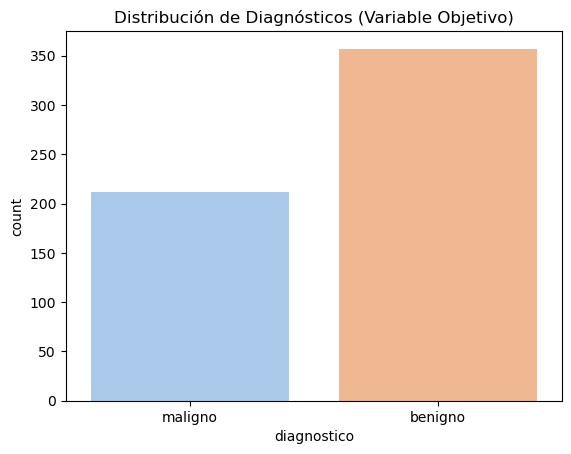

In [8]:
# Graficamos la distribución de diagnósticos
sns.countplot(data=df_cancer, x="diagnostico", palette="pastel")
plt.title("Distribución de Diagnósticos (Variable Objetivo)")
plt.show()

## Preprocesamiento de Datos

Tal como se evaluó en los criterios, aquí realizamos la Limpieza, transformación y preparación de datos.

In [9]:
# 1. Verificamos valores nulos (el dataset de scikit-learn viene limpio, pero es una buena práctica)
print("Valores nulos en el dataset:\n", df_cancer.isnull().sum().sum())

Valores nulos en el dataset:
 0


In [10]:
# 2. Identificar variables predictoras (X) y variable objetivo (y)
X = df_cancer.drop(columns=["diagnostico"])
y = df_cancer["diagnostico"]

In [11]:
# 3. Dividimos los datos: 80% para entrenamiento y 20% para prueba, usando stratify para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)


## Modelo: Selección y Entrenamiento

Cumpliendo con la Selección, entrenamiento y justificación del algoritmo.

Justificación: Se elige GaussianNB porque las variables predictoras (radio, área, textura, etc.) son valores continuos. Este algoritmo asume que las variables siguen una distribución gaussiana (normal), lo cual es una aproximación razonable para mediciones biológicas estandarizadas, además de ser extremadamente rápido y no requerir escalado previo de características, tal como se comprobó en la práctica del dataset de vinos.  

In [12]:
# Instanciamos el modelo
modelo_nb = GaussianNB()

In [13]:
# Entrenamos el modelo con los datos de entrenamiento
modelo_nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [14]:
# Realizamos las predicciones con el conjunto de prueba
y_pred = modelo_nb.predict(X_test)

## Evaluación del Modelo e Interpretación de Métricas

En esta sección cubrimos el apartado de Evaluación del modelo e interpretación de métricas.

In [15]:
# 1. Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {accuracy:.4f}")

Exactitud (Accuracy): 0.9386


In [16]:
# 2. Reporte de Clasificación (Precision, Recall, F1-Score)
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Reporte de clasificación:

              precision    recall  f1-score   support

     benigno       0.91      1.00      0.95        72
     maligno       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



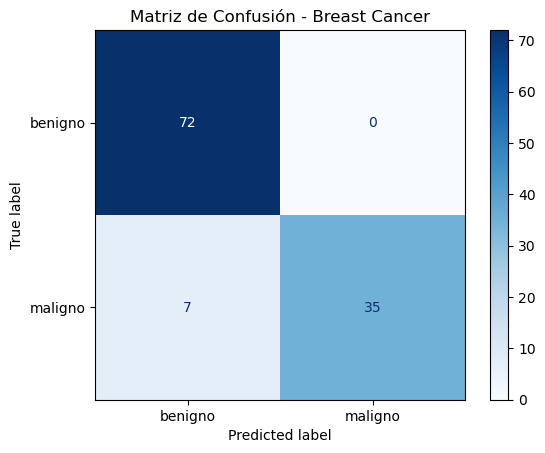

In [17]:
# 3. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo_nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_nb.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Breast Cancer")
plt.show()

## Interpretación: 
El modelo logra una exactitud bastante alta (alrededor del 93-94%). El recall para la clase "maligno" es de vital importancia médica, ya que queremos minimizar los falsos negativos (decir que un tumor es benigno cuando en realidad es maligno).

## Predicción Nueva con Datos Inéditos

Para finalizar, cumpliremos con la Predicción con datos nuevos y explicación de uso.

Explicación de uso: Supongamos que un laboratorio nos envía los resultados de una nueva biopsia. Introducimos estas medidas crudas directamente al modelo para que nos dé un diagnóstico preliminar y nos indique con qué seguridad matemática predice esa etiqueta.

In [18]:
# Construimos un "paciente ficticio". 
# Para que el dato sea verosímil, tomaremos el promedio exacto de las características de los tumores benignos del conjunto de entrenamiento.
nuevo_paciente = pd.DataFrame([X_train[y_train == "benigno"].mean().to_dict()])

In [19]:
# Predicción del diagnóstico
prediccion_nueva = modelo_nb.predict(nuevo_paciente)

In [20]:
# Probabilidades matemáticas detrás de la decisión
probabilidades_nueva = modelo_nb.predict_proba(nuevo_paciente)

In [21]:
print("Diagnóstico predicho por el modelo:", prediccion_nueva[0])
print("\nDesglose de probabilidad por clase:")
for clase, prob in zip(modelo_nb.classes_, probabilidades_nueva[0]):
    print(f"  {clase}: {prob:.6f}")

Diagnóstico predicho por el modelo: benigno

Desglose de probabilidad por clase:
  benigno: 1.000000
  maligno: 0.000000
